 # Customer Churn Analysis (Banking Dataset)



 ## Executive Summary

 This project analyzes customer churn (`Exited`) in a banking dataset to identify the main churn drivers,

 discover high-risk customer segments, and propose practical retention actions.



 The analysis focuses on:

 - the overall churn baseline,

 - key segment-level churn patterns,

 - selected multivariate interactions,

 - final high-risk segments,

 - and business recommendations.



 The project is intentionally positioned as an **exploratory and segmentation-based Data Analyst case study**.

 Predictive modeling is treated as a possible follow-up step, not as the main goal of this notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

 ## 1) Business context



 ### Business question

 Which customer segments are more likely to churn, and what patterns can help explain churn behavior?



 ### Target definition

 `Exited`

 - `1` = customer churned

 - `0` = customer retained



 ### Unit of analysis

 One row represents one customer.



 ### Scope

 This notebook focuses on:

 - dataset overview and sanity checks,

 - data quality review,

 - exploratory analysis,

 - multivariate segment discovery,

 - key findings and business recommendations.

 ## 2) Load data

In [4]:
df = pd.read_csv("../data/churn.csv")


 ## 3) Dataset overview and sanity checks



 This section verifies:

 - dataset shape,

 - column structure,

 - duplicate rows / duplicate customer IDs,

 - target consistency,

 - identifier-like columns that should not be used as analytical features.

In [5]:
print("Dataset shape:", df.shape)
display(df.head(3))

print("\nColumn info:")
df.info()

print("\nMissing values by column:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

if "CustomerId" in df.columns:
    print("Duplicate CustomerId:", df["CustomerId"].duplicated().sum())

assert "Exited" in df.columns, "Target column 'Exited' not found."

target_summary = pd.DataFrame({
    "count": df["Exited"].value_counts(dropna=False),
    "pct": (df["Exited"].value_counts(normalize=True, dropna=False) * 100).round(2)
})
print("\nTarget distribution:")
display(target_summary)

unique_target = set(df["Exited"].dropna().unique())
print("Unique values in Exited:", unique_target)

id_like_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
print("Identifier-like columns:", id_like_cols)


Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1



Column info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB

Missing values by column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicate rows: 0
Duplicate CustomerId: 0

Target distribution:


,count,pct
Exited,,
0,7963,79.63
1,2037,20.37


Unique values in Exited: {np.int64(0), np.int64(1)}
Identifier-like columns: ['RowNumber', 'CustomerId', 'Surname']


 ### Sanity check summary



 The dataset contains **10,000 customers** and appears suitable for segmentation analysis.



 Main checks:

 - no missing values were detected,

 - no duplicate rows were found,

 - no duplicate `CustomerId` values were found,

 - the target variable `Exited` is clean and binary,

 - identifier-like fields (`RowNumber`, `CustomerId`, `Surname`) will be excluded from analytical interpretation.



 Overall, the dataset is sufficiently clean to proceed with exploratory analysis without major preprocessing steps.

 ## 4) Data quality review



 This section performs a compact review of:

 - numeric ranges,

 - selected categorical distributions,

 - and the special case of `Balance = 0`, which appears frequently in the dataset.

In [6]:
numeric_cols = ["Age", "Tenure", "CreditScore", "NumOfProducts", "Balance", "EstimatedSalary"]

print("Numeric ranges:")
for col in numeric_cols:
    if col in df.columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")

print("\nBasic plausibility checks:")
if "Age" in df.columns:
    print("Customers with Age < 18:", (df["Age"] < 18).sum())
    print("Customers with Age > 100:", (df["Age"] > 100).sum())

if "Tenure" in df.columns:
    print("Customers with Tenure < 0:", (df["Tenure"] < 0).sum())
    print("Customers with Tenure > 10:", (df["Tenure"] > 10).sum())

print("\nSelected categorical distributions:")
for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts())

print("\nBalance summary:")
display(df["Balance"].describe(percentiles=[0.25, 0.50, 0.75, 0.99]))

balance_zero_count = (df["Balance"] == 0).sum()
print("Customers with Balance = 0:", balance_zero_count)


Numeric ranges:
Age: min=18, max=92
Tenure: min=0, max=10
CreditScore: min=350, max=850
NumOfProducts: min=1, max=4
Balance: min=0.0, max=250898.09
EstimatedSalary: min=11.58, max=199992.48

Basic plausibility checks:
Customers with Age < 18: 0
Customers with Age > 100: 0
Customers with Tenure < 0: 0
Customers with Tenure > 10: 0

Selected categorical distributions:

Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64

HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

NumOfProducts
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Balance summary:


count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
99%      185967.985400
max      250898.090000
Name: Balance, dtype: float64

Customers with Balance = 0: 3617


 ### Data quality summary



 Numeric ranges are plausible overall, and no major data integrity issues emerged from the quick checks.



 Two observations are especially relevant for the analysis:

 - `Balance` includes a substantial number of customers with **zero balance**,

 - `NumOfProducts` is highly concentrated in the **1-product** and **2-product** groups, while **3+ products** is relatively rare.



 These patterns are not necessarily data quality problems, but they are important for interpretation because they affect segment sizes and stability.

 ## 5) Feature engineering for analysis



 To support segmentation, I create a small set of derived variables that are easier to interpret than raw numeric values alone.

In [7]:
baseline_rate = df["Exited"].mean()
baseline_pct = baseline_rate * 100

df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18–30", "31–40", "41–50", "51–60", "61+"],
    include_lowest=True
)

df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=[349, 499, 599, 699, 799, 850],
    labels=["350–499", "500–599", "600–699", "700–799", "800–850"]
)

df["HasBalance"] = (df["Balance"] > 0).astype(int)

df["SalaryDecile"] = pd.qcut(
    df["EstimatedSalary"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

df["NumProductsGroup"] = df["NumOfProducts"].apply(lambda x: "3+" if x >= 3 else str(int(x)))
df["NumProductsGroup"] = pd.Categorical(
    df["NumProductsGroup"],
    categories=["1", "2", "3+"],
    ordered=True
)


 ## 6) Baseline churn rate



 The overall churn rate is the baseline against which all segments are compared.

In [ ]:
print(f"Overall churn rate: {baseline_pct:.2f}%")

Overall churn rate: 20.37%


 ### Baseline interpretation



 The overall churn rate is **20.37%**, which indicates a **moderate churn level** in this dataset.



 Throughout the analysis, segment-level churn is evaluated against this baseline using:

 - **churn rate**,

 - **segment size**,

 - and **lift vs baseline**.



 This is more informative than relying on raw counts alone.

 ## 7) Helper functions

In [9]:
def countplot_with_percent(df, col, title=None, figsize=(7, 4), color="#4C72B0"):
    order = df[col].value_counts().index
    counts = df[col].value_counts().reindex(order)
    perc = counts / counts.sum() * 100

    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df, x=col, order=order, color=color)
    ax.set_title(title or f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of customers")

    max_count = counts.max()
    for i, cat in enumerate(order):
        ax.text(
            i,
            counts.loc[cat] + max_count * 0.02,
            f"{perc.loc[cat]:.1f}%",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


def summarize_churn(df, group_col, target="Exited"):
    summary = (
        df.groupby(group_col, observed=True)
          .agg(customers=(target, "size"), churn_rate=(target, "mean"))
          .reset_index()
    )
    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    summary["lift_vs_baseline"] = summary["churn_rate"] / baseline_rate
    return summary


def plot_churn_bar(summary, x_col, title, color="#E67E22", figsize=(8, 4)):
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=summary, x=x_col, y="churn_rate_pct", color=color)

    ax.axhline(baseline_pct, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Churn rate (%)")

    for i, row in summary.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["churn_rate_pct"] + 0.5,
            f"{row['churn_rate_pct']:.1f}%\n(n={int(row['customers'])})",
            ha="center",
            fontsize=9
        )

    plt.ylim(0, summary["churn_rate_pct"].max() + 6)
    plt.tight_layout()
    plt.show()


def churn_heatmap(df, row_var, col_var, target="Exited", show_counts=True, figsize=(8, 5)):
    rate = df.pivot_table(values=target, index=row_var, columns=col_var, aggfunc="mean") * 100
    counts = df.pivot_table(values=target, index=row_var, columns=col_var, aggfunc="size")

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        rate.round(1),
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        cbar_kws={"label": "Churn rate (%)"}
    )
    ax.set_title(f"Churn rate (%) — {row_var} × {col_var}\nBaseline = {baseline_pct:.2f}%")
    ax.set_xlabel(col_var)
    ax.set_ylabel(row_var)
    plt.tight_layout()
    plt.show()

    if show_counts:
        plt.figure(figsize=figsize)
        ax = sns.heatmap(
            counts.fillna(0).astype(int),
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar_kws={"label": "Customers (n)"}
        )
        ax.set_title(f"Segment size (n) — {row_var} × {col_var}")
        ax.set_xlabel(col_var)
        ax.set_ylabel(row_var)
        plt.tight_layout()
        plt.show()

    return rate, counts


 ## 8) Exploratory analysis



 The goal of this section is to identify which variables show the most meaningful standalone relationship with churn.



 I focus on:

 - key distributions,

 - churn rate by segment,

 - and the variables that are strongest enough to justify multivariate analysis.

 ### 8.1 Key distributions

 #### Age distribution by churn status



 Age is one of the most relevant continuous variables in this dataset, so I inspect it before moving to age-based segmentation.

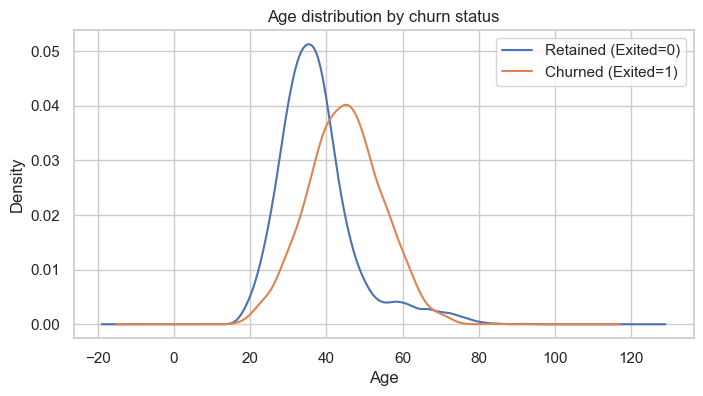

In [10]:
ax = df.loc[df["Exited"] == 0, "Age"].plot(
    kind="density",
    label="Retained (Exited=0)",
    figsize=(8, 4)
)
df.loc[df["Exited"] == 1, "Age"].plot(
    kind="density",
    label="Churned (Exited=1)",
    ax=ax
)
ax.set_title("Age distribution by churn status")
ax.set_xlabel("Age")
ax.legend()
plt.show()


 The churn distribution is visibly shifted toward older ages, suggesting that customers who churn tend to be older on average.



 Although age alone does not perfectly separate churners from retained customers, it appears strong enough to justify **age-banded churn analysis**.

 #### Categorical variable distributions



 These charts help evaluate category balance before comparing churn rates across groups.

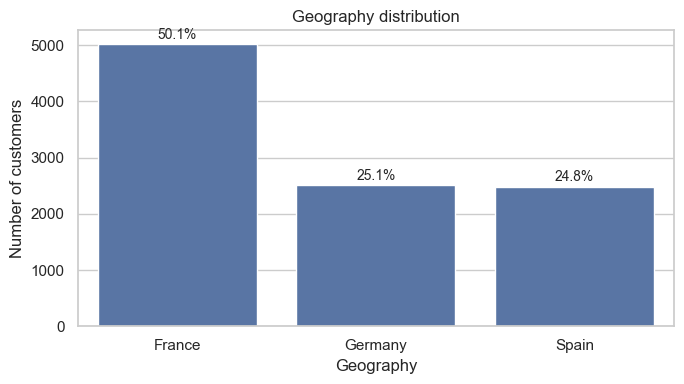

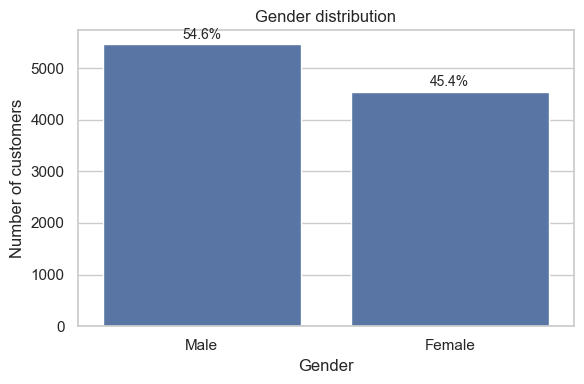

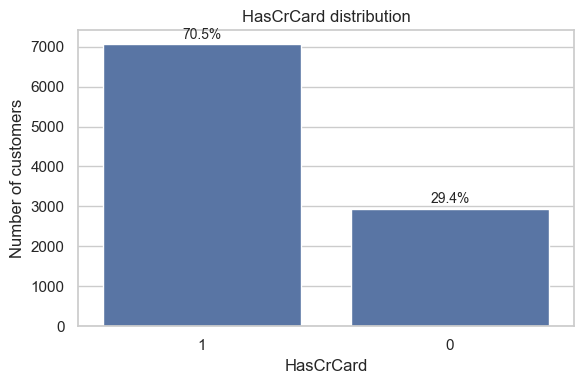

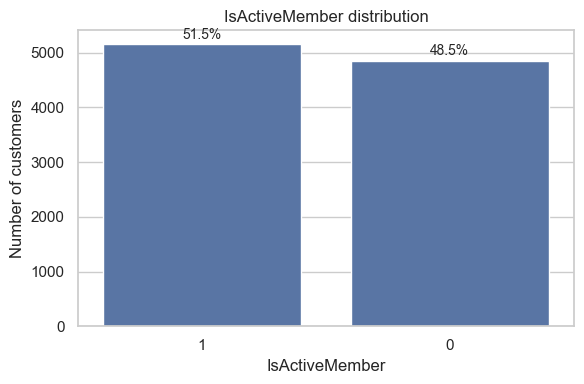

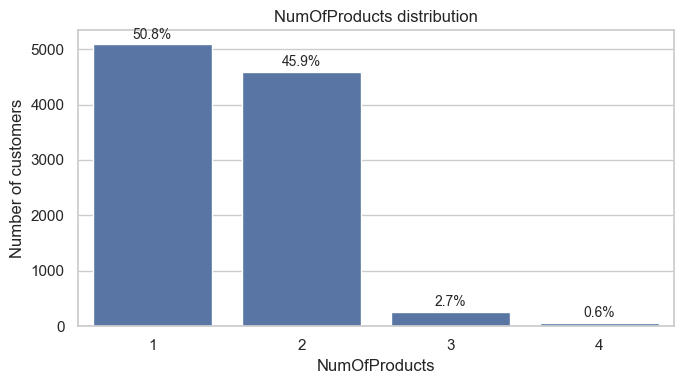

In [11]:
countplot_with_percent(df, "Geography", title="Geography distribution", figsize=(7, 4))
countplot_with_percent(df, "Gender", title="Gender distribution", figsize=(6, 4))
countplot_with_percent(df, "HasCrCard", title="HasCrCard distribution", figsize=(6, 4))
countplot_with_percent(df, "IsActiveMember", title="IsActiveMember distribution", figsize=(6, 4))
countplot_with_percent(df, "NumOfProducts", title="NumOfProducts distribution", figsize=(7, 4))


 ### Distribution takeaways



 A few structural patterns are relevant before segment-level churn comparisons:



 - **France** represents roughly half of the customer base, while **Germany** and **Spain** are smaller but still substantial.

 - **Gender** is reasonably balanced, making comparisons meaningful.

 - **IsActiveMember** is also well balanced, which makes it especially useful for segmentation.

 - **NumOfProducts** is highly concentrated in the **1-product** and **2-product** groups, while **3+ products** is relatively rare and should be interpreted with caution.

 ### 8.2 Bivariate churn analysis



 In this section, I compare churn rates across the most relevant variables and identify which ones should be prioritized in multivariate segment discovery.

 #### AgeBand

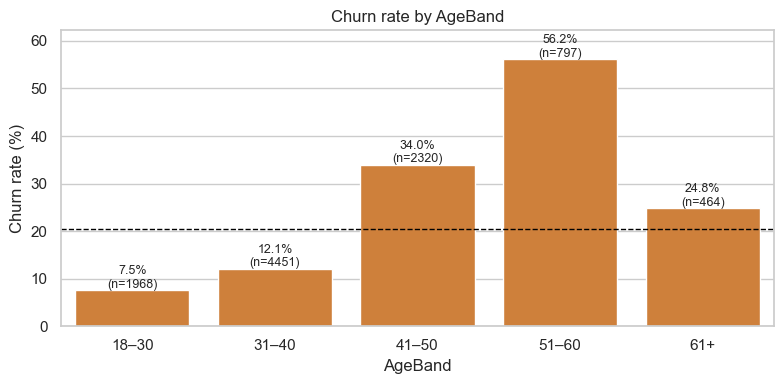

In [ ]:
age_churn = summarize_churn(df, "AgeBand")
plot_churn_bar(age_churn, "AgeBand", "Churn rate by AgeBand")

 Churn rises sharply with age up to the **51–60** segment:



 - **18–30:** ~8%

 - **31–40:** ~12%

 - **41–50:** ~34%

 - **51–60:** ~56%

 - **61+:** ~25%



 **Interpretation:** age is one of the strongest segmentation variables in the dataset, especially in the **41–60** range.

 #### Geography

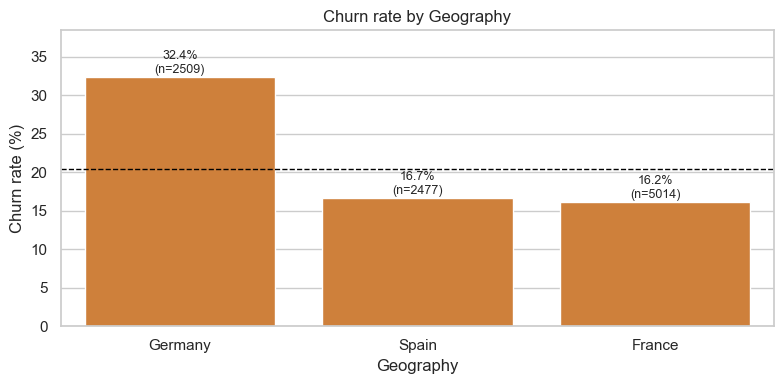

In [ ]:
geo_churn = summarize_churn(df, "Geography").sort_values("churn_rate_pct", ascending=False)
plot_churn_bar(geo_churn, "Geography", "Churn rate by Geography")

 **Germany** shows the highest churn rate at **32.4%**, compared with roughly **16–17%** in France and Spain.



 **Interpretation:** geography is a strong churn segmentation variable, and Germany stands out as the highest-risk market.

 #### Gender

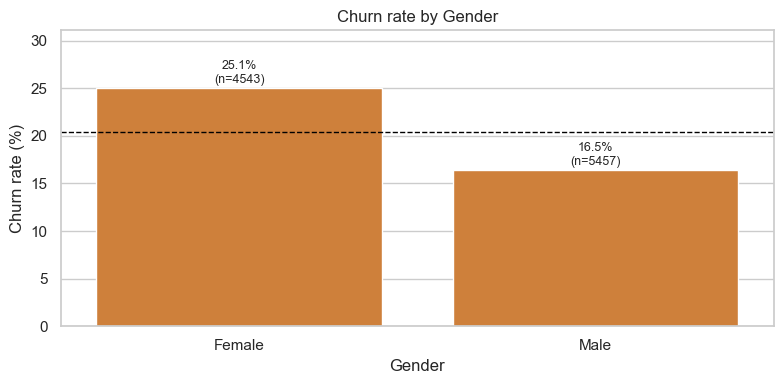

In [ ]:
gender_churn = summarize_churn(df, "Gender").sort_values("churn_rate_pct", ascending=False)
plot_churn_bar(gender_churn, "Gender", "Churn rate by Gender")

 Female customers show higher churn than male customers.



 **Interpretation:** gender has a moderate relationship with churn, but it should not be interpreted in isolation or over-attributed.

 #### IsActiveMember

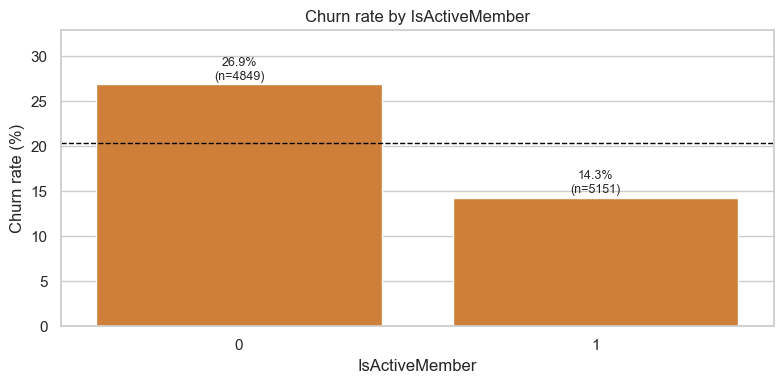

In [ ]:
active_churn = summarize_churn(df, "IsActiveMember").sort_values("churn_rate_pct", ascending=False)
plot_churn_bar(active_churn, "IsActiveMember", "Churn rate by IsActiveMember")

 Inactive customers churn at **26.9%**, versus **14.3%** for active customers.



 **Interpretation:** `IsActiveMember` is one of the strongest and most actionable variables in the dataset, likely acting as a proxy for engagement.

 #### NumProductsGroup

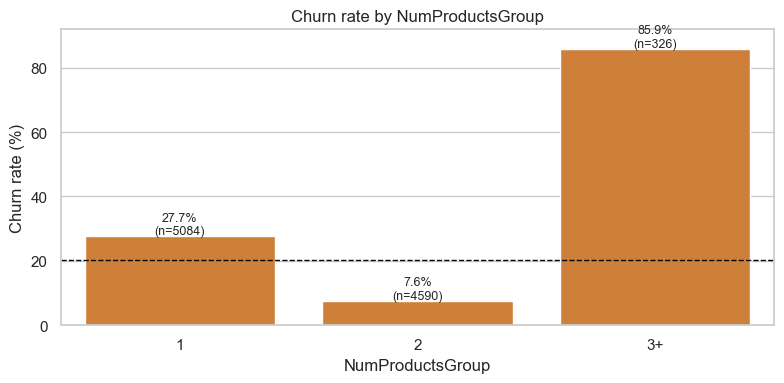

In [ ]:
prod_churn = summarize_churn(df, "NumProductsGroup")
plot_churn_bar(prod_churn, "NumProductsGroup", "Churn rate by NumProductsGroup")

 The relationship between churn and number of products is non-linear:



 - **2 products** has the lowest churn,

 - **1 product** is slightly above baseline,

 - **3+ products** shows extremely high churn but is much smaller in size.



 **Interpretation:** `NumProductsGroup` is useful, but the **3+ products** segment should be treated cautiously because of limited volume.

 #### HasBalance

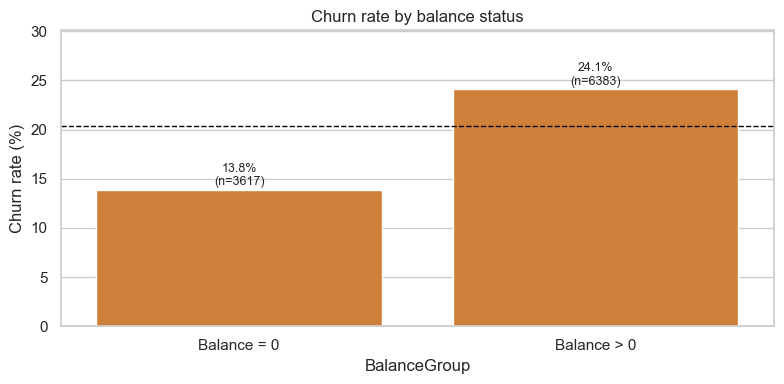

In [17]:
bal_churn = summarize_churn(df, "HasBalance")
bal_churn["BalanceGroup"] = bal_churn["HasBalance"].map({0: "Balance = 0", 1: "Balance > 0"})
plot_churn_bar(bal_churn, "BalanceGroup", "Churn rate by balance status")


 Customers with **Balance > 0** show materially higher churn than customers with **Balance = 0**.



 **Interpretation:** balance is a useful segmentation signal, although it is more meaningful as a broad relationship flag than as a standalone driver.

 ### Bivariate summary



 The strongest variables for segment discovery are:

 - **AgeBand**

 - **Geography**

 - **IsActiveMember**

 - **NumProductsGroup**

 - **HasBalance**



 By contrast, **Tenure**, **EstimatedSalary**, and **CreditScore** show weaker standalone relationships with churn and are not prioritized in the multivariate stage.

 ## 9) Multivariate analysis and segment discovery



 Rather than testing every possible pair, I focus on a small set of **strategic two-variable combinations**.



 I use `IsActiveMember` as the main interaction anchor because it is both:

 - one of the strongest bivariate signals,

 - and one of the most actionable variables from a business perspective.



 I also add **AgeBand × Geography** as a validation view to avoid over-centering the analysis on engagement alone.

 ### 9.1 AgeBand × IsActiveMember

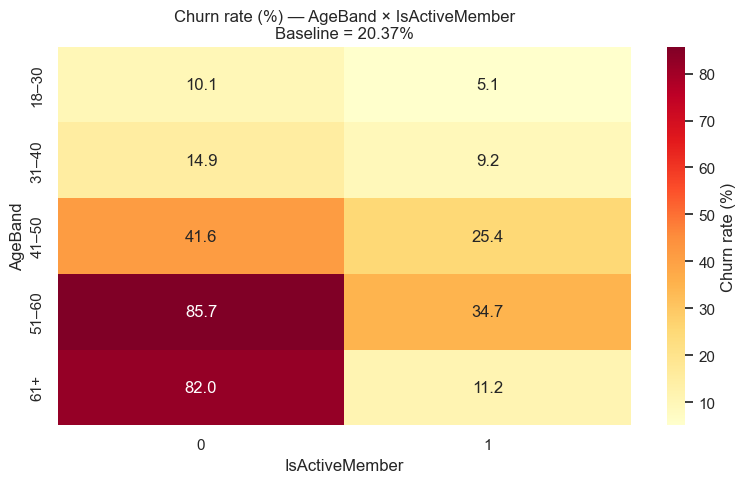

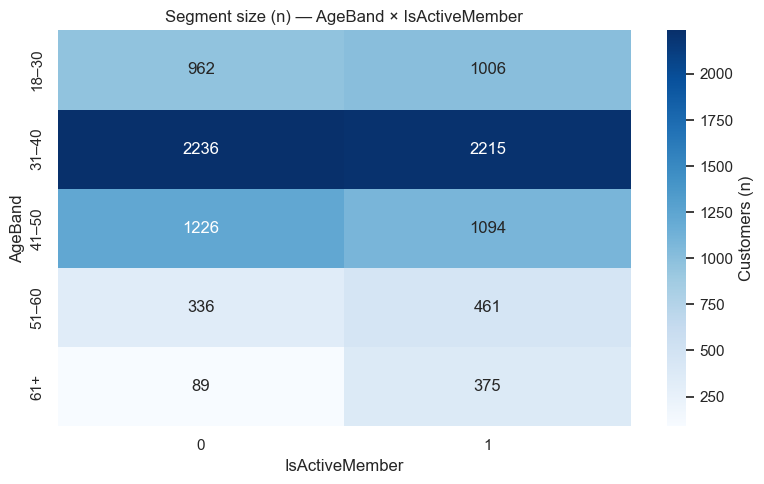

In [ ]:
rate1, n1 = churn_heatmap(
    df,
    row_var="AgeBand",
    col_var="IsActiveMember",
    show_counts=True
)

 This heatmap shows that **inactivity strongly amplifies churn risk across age groups**, especially among older customers.



 Key points:

 - younger customers remain relatively low-risk in both activity states,

 - churn rises sharply from **41+**, especially among inactive customers,

 - **Inactive customers aged 41–50** reach **41.6% churn** with **n=1,226**,

 - **Inactive customers aged 51–60** reach **85.7% churn**, but with a smaller segment size (**n=336**).



 **Interpretation:** age and inactivity reinforce each other, making older inactive customers a clear retention priority.

 ### 9.2 Geography × IsActiveMember

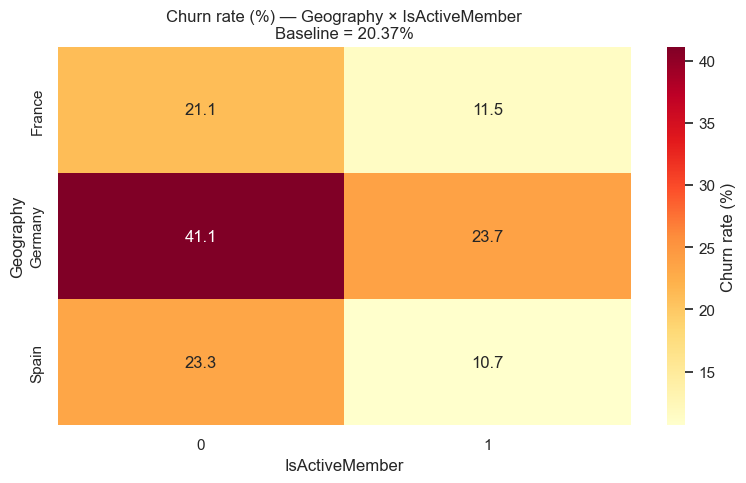

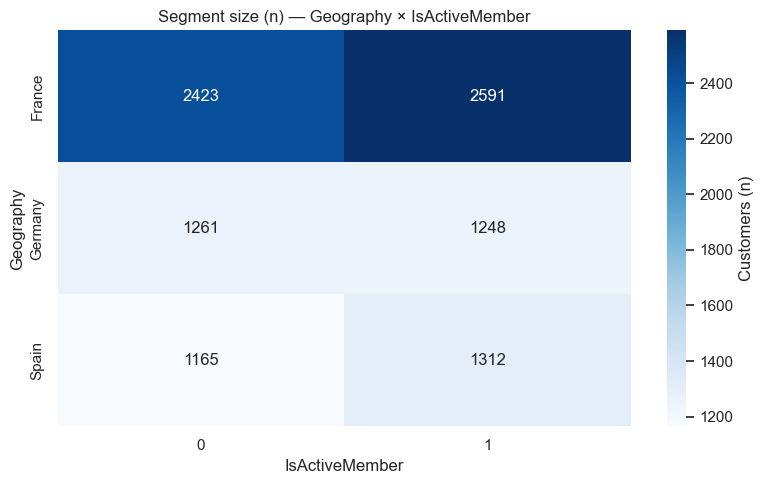

In [ ]:
rate2, n2 = churn_heatmap(
    df,
    row_var="Geography",
    col_var="IsActiveMember",
    show_counts=True
)

 This heatmap shows that **Germany remains the highest-risk geography**, and that inactivity further increases churn within that market.



 Key points:

 - **Inactive customers in Germany** reach **41.1% churn** with **n=1,261**,

 - even **active customers in Germany** remain above the global baseline,

 - France and Spain show materially lower churn in both activity states.



 **Interpretation:** Germany appears to be a structurally higher-risk market, while inactivity further amplifies churn within it.

 ### 9.3 NumProductsGroup × IsActiveMember

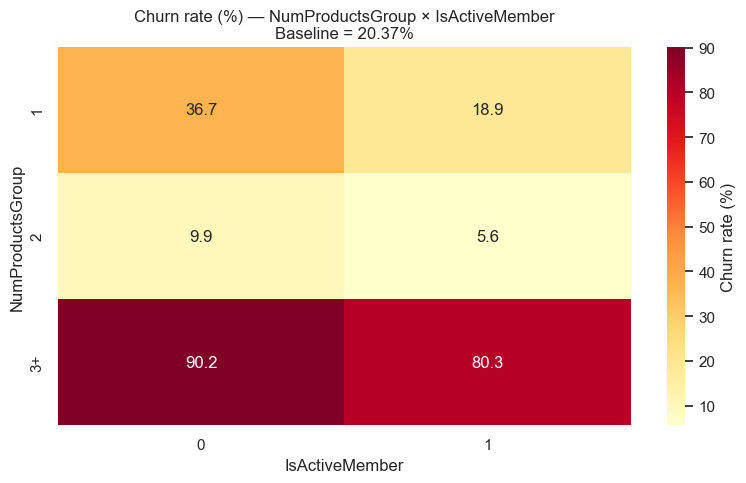

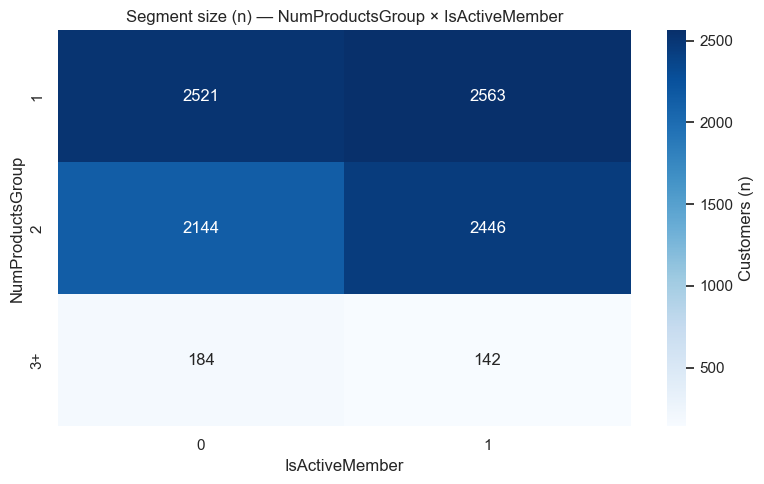

In [ ]:
rate3, n3 = churn_heatmap(
    df,
    row_var="NumProductsGroup",
    col_var="IsActiveMember",
    show_counts=True
)

 This heatmap shows a strong interaction between **product depth** and **engagement**.



 Key points:

 - **Inactive customers with 1 product** reach **36.7% churn** with **n=2,521**,

 - customers with **2 products** show the lowest churn in both activity states,

 - **3+ product customers** show extremely high churn, but the segment is much smaller.



 **Interpretation:** low engagement combined with a shallow customer relationship is a strong churn pattern. The very high churn among **3+ product customers** is noteworthy, but should be treated as a red flag rather than as a core segment without further validation.

 ### 9.4 AgeBand × Geography

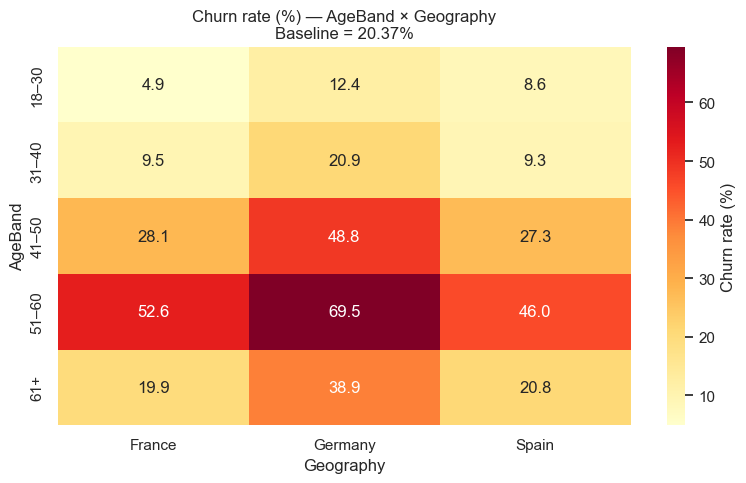

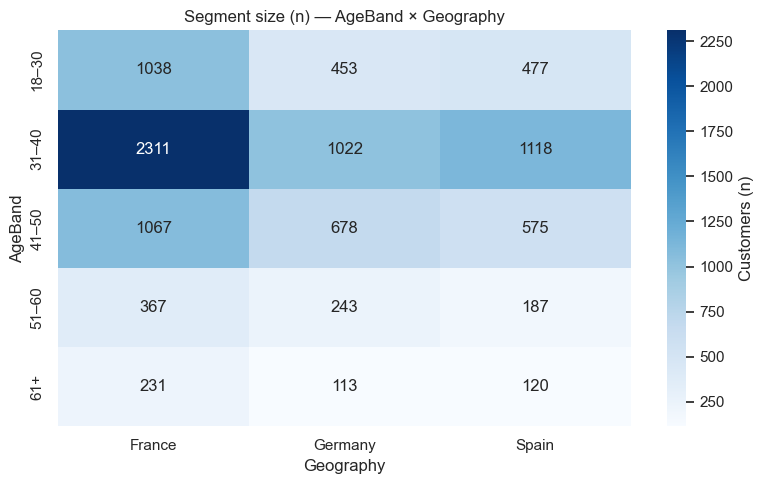

In [ ]:
rate4, n4 = churn_heatmap(
    df,
    row_var="AgeBand",
    col_var="Geography",
    show_counts=True
)

 This validation heatmap shows that churn varies across both **age** and **geography**, and that the two effects reinforce each other.



 Key points:

 - churn tends to increase with age in all three countries,

 - **Germany shows the highest churn rate in every age band**,

 - the strongest pattern appears in the **41–60** range, especially in Germany.



 **Interpretation:** churn is not driven by age alone. Germany remains a systematically higher-risk geography even when controlling for age group.

 ### Multivariate summary



 Across the selected combinations, churn becomes especially concentrated when **inactivity** is combined with:

 - **older age**,

 - **German geography**,

 - or a **shallow product relationship (1 product)**.



 These patterns support a segmentation-based interpretation of churn and provide a strong basis for actionable retention recommendations.

 ## 10) Final priority segments



 To close the analysis, I summarize the most relevant churn segments by balancing:

 - churn rate,

 - segment size,

 - lift vs baseline,

 - interpretability,

 - and actionability.

In [ ]:
def summarize_segment(df, mask, segment_name, priority):
    n = mask.sum()
    churn_rate = df.loc[mask, "Exited"].mean()
    return {
        "Segment": segment_name,
        "Customers": int(n),
        "Customer Share %": round(n / len(df) * 100, 2),
        "Churn Rate %": round(churn_rate * 100, 2),
        "Lift vs Baseline": round(churn_rate / baseline_rate, 2),
        "Priority": priority
    }

segments = [
    summarize_segment(
        df,
        (df["IsActiveMember"] == 0) & (df["AgeBand"] == "41–50"),
        "Inactive, age 41–50",
        "Main"
    ),
    summarize_segment(
        df,
        (df["IsActiveMember"] == 0) & (df["Geography"] == "Germany"),
        "Inactive, Germany",
        "Main"
    ),
    summarize_segment(
        df,
        (df["IsActiveMember"] == 0) & (df["NumProductsGroup"] == "1"),
        "Inactive, 1 product",
        "Main"
    ),
    summarize_segment(
        df,
        (df["NumProductsGroup"] == "3+"),
        "3+ products",
        "Red flag"
    ),
    summarize_segment(
        df,
        (df["IsActiveMember"] == 0) & (df["AgeBand"] == "51–60"),
        "Inactive, age 51–60",
        "Red flag"
    )
]

final_segments = pd.DataFrame(segments)

priority_order = {"Main": 0, "Red flag": 1}
final_segments["priority_order"] = final_segments["Priority"].map(priority_order)

final_segments = (
    final_segments
    .sort_values(by=["priority_order", "Churn Rate %"], ascending=[True, False])
    .drop(columns="priority_order")
    .reset_index(drop=True)
)

final_segments_display = final_segments[
    ["Segment", "Customers", "Customer Share %", "Churn Rate %", "Lift vs Baseline", "Priority"]
].copy()

final_segments_display["Customer Share %"] = final_segments_display["Customer Share %"].map(lambda x: f"{x:.2f}%")
final_segments_display["Churn Rate %"] = final_segments_display["Churn Rate %"].map(lambda x: f"{x:.2f}%")
final_segments_display["Lift vs Baseline"] = final_segments_display["Lift vs Baseline"].map(lambda x: f"{x:.2f}x")

display(final_segments_display)

,Segment,Customers,Customer Share %,Churn Rate %,Lift vs Baseline,Priority
0,"Inactive, age 41–50",1226,12.26%,41.60%,2.04x,Main
1,"Inactive, Germany",1261,12.61%,41.08%,2.02x,Main
2,"Inactive, 1 product",2521,25.21%,36.65%,1.80x,Main
3,3+ products,326,3.26%,85.89%,4.22x,Red flag
4,"Inactive, age 51–60",336,3.36%,85.71%,4.21x,Red flag


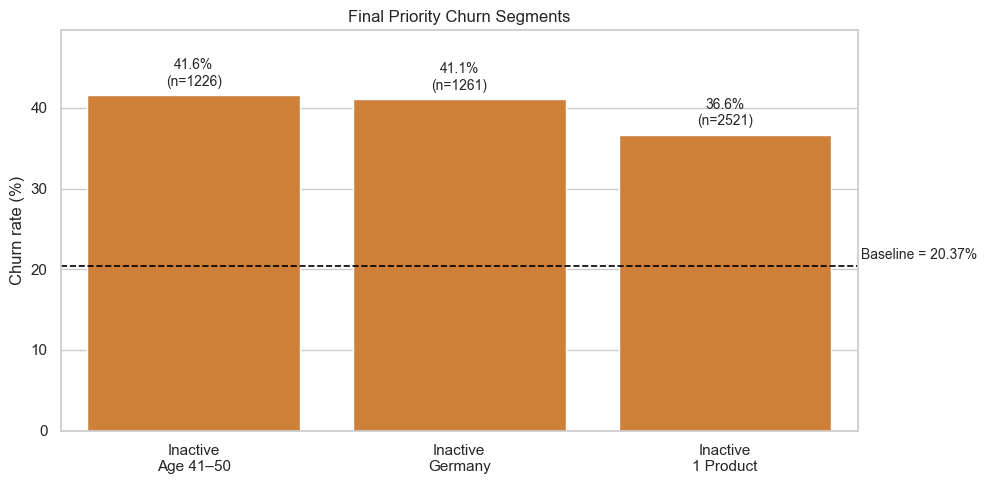

In [ ]:
plot_df = final_segments[final_segments["Priority"] == "Main"].copy()

label_map = {
    "Inactive, age 41–50": "Inactive\nAge 41–50",
    "Inactive, Germany": "Inactive\nGermany",
    "Inactive, 1 product": "Inactive\n1 Product"
}
plot_df["PlotLabel"] = plot_df["Segment"].map(label_map)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="PlotLabel", y="Churn Rate %", color="#E67E22")

ax.axhline(baseline_pct, color="black", linestyle="--", linewidth=1.2)
ax.text(
    len(plot_df) - 0.05,
    baseline_pct + 0.5,
    f"Baseline = {baseline_pct:.2f}%",
    ha="right",
    va="bottom",
    fontsize=10
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["Churn Rate %"] + 0.8,
        f"{row['Churn Rate %']:.1f}%\n(n={row['Customers']})",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Final Priority Churn Segments")
ax.set_xlabel("")
ax.set_ylabel("Churn rate (%)")
ax.set_ylim(0, plot_df["Churn Rate %"].max() + 8)

plt.tight_layout()
plt.show()

 ### Final segment interpretation



 - **Inactive, age 41–50** — This is a large, high-risk segment (**41.6% churn; n=1,226**) with churn at about **2.0x the baseline**. It suggests that disengagement becomes especially critical among customers in the **41–50** age band.



 - **Inactive, Germany** — German inactive customers show **41.1% churn (n=1,261)**, again roughly **2.0x the baseline**. This reinforces the idea that Germany is a structurally higher-risk market, especially when low engagement is present.



 - **Inactive, 1 product** — This is the **largest actionable segment** (**36.7% churn; n=2,521**) and likely reflects a shallow customer relationship combined with low engagement.



 - **3+ products** — Customers with **3+ products** show extremely high churn (**85.9%; n=326**), but the segment is relatively small. This should be treated as a **red flag** rather than as a core segment.



 - **Inactive, age 51–60** — This segment has **very high churn (85.7%; n=336)**, making it one of the most at-risk groups in the dataset. However, it is smaller than the main priority segments and should be interpreted more cautiously.

 ## 11) Key findings



 1. **Age is one of the strongest churn segmentation variables in the dataset.**

    Churn rises sharply from age **41+**, with the highest risk in the **51–60** band.



 2. **Germany is the highest-risk geography.**

    Its churn rate is materially above France and Spain in both bivariate and multivariate views.



 3. **Inactive customers are consistently more likely to churn.**

    `IsActiveMember` is one of the clearest and most actionable churn signals.



 4. **The largest actionable high-risk segment is inactive customers with 1 product.**

    This suggests that a shallow customer relationship combined with low engagement is especially fragile.



 5. **Some niche groups show extreme churn, but should be treated cautiously.**

    In particular, **inactive customers aged 51–60** and **customers with 3+ products** are high-risk but smaller in size.

 ## 12) Recommendations



 ### 1. Segment: **Inactive customers with 1 product**

 **Action:** Launch a targeted re-engagement campaign combining personalized reminders, usage nudges, and selective cross-sell offers.

 **Rationale:** This is the **largest actionable high-risk segment** in the dataset, suggesting a shallow relationship combined with low engagement.

 **Measure:** churn rate in this segment, reactivation rate, product adoption uplift, and 30/60/90-day retention.



 ### 2. Segment: **Inactive customers aged 41–50**

 **Action:** Create a retention journey for this age band with proactive outreach and messaging focused on convenience, trust, and account value.

 **Rationale:** This segment shows **41.6% churn**, around **2.0x the baseline**, indicating that disengagement is especially critical in this group.

 **Measure:** churn rate, response rate to outreach, reactivation rate, and short-term retention after intervention.



 ### 3. Segment: **Inactive customers in Germany**

 **Action:** Prioritize Germany for localized retention analysis and pilot a market-specific retention program for inactive customers.

 **Rationale:** This segment reaches **41.1% churn**, suggesting that low engagement interacts with a broader geography-related risk.

 **Measure:** churn rate in the German inactive segment, response rate, reactivation rate, and pre/post comparison versus France and Spain.

 ## 13) Limitations and next steps



 ### Limitations

 - This is an observational dataset, so the analysis identifies **associations**, not causality.

 - Some variables may act as proxies for broader business factors that are not directly observed in the data.

 - Some high-risk segments are relatively small, so their churn rates should be interpreted with caution.



 ### Next steps

 - Predict the target variable in a new dataset of customers of the same bank with a simple machine learning Classification Model.

 - Extend the analysis with time-based data if available.

 - Build a dashboard to monitor churn by segment over time.